In [1]:
!pip install yfinance

In [13]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dropout, Dense, Bidirectional


In [3]:
stock_symbol = 'AMZN'
start_date = '2020-01-01'
end_date = '2021-12-31'
data = yf.download(stock_symbol, start=start_date, end=end_date)
data

/tmp/ipython-input-2093372977.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000
...,...,...,...,...,...
2021-12-23,171.068497,171.975006,170.149994,170.427994,36788000
2021-12-27,169.669495,172.942993,169.215500,171.037003,58688000


In [4]:
data = data[['Close']]
data

Price,Close
Ticker,AMZN
Date,
2020-01-02,94.900497
2020-01-03,93.748497
2020-01-06,95.143997
2020-01-07,95.343002
2020-01-08,94.598503
...,...
2021-12-23,171.068497
2021-12-27,169.669495


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [26]:
def create_sequences(data, time_s=100):
    x, y = [], []
    for i in range(len(data) - time_s - 1):
        x.append(data[i:(i + time_s), 0])
        y.append(data[i + time_s, 0])
    return np.array(x), np.array(y)

x, y = create_sequences(scaled_data)
train_size = int(0.8 * len(x))
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
x_train.shape, x_test.shape

((322, 100, 1), (81, 100, 1))

In [99]:
model = Sequential()

model.add(Bidirectional(LSTM(units=100, return_sequences=True),
                        input_shape=(x_train.shape[1], 1)))

model.add(Bidirectional(LSTM(units=100, return_sequences=False)))

model.add(Dense(units=1))
optimizer = Adam(learning_rate=0.004)
model.compile(optimizer=optimizer, loss='mean_squared_error')

history = model.fit(x_train, y_train, batch_size=64, epochs=60, validation_data=(x_test, y_test), verbose=1)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 716ms/step - loss: 0.2802 - val_loss: 0.0126
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 811ms/step - loss: 0.0088 - val_loss: 0.0074
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 548ms/step - loss: 0.0054 - val_loss: 0.0024
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 552ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 821ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 553ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 549ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 701ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 9/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 539ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 10/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 550ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 11/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 590ms/step - loss: 0.0019 - val_loss: 0.0021
Epoch 12/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 551ms/step - loss: 0.0028 - val_loss: 0.0014

In [100]:
predicted_price = model.predict(x_test)
predicted_price = scaler.inverse_transform(predicted_price)
actual_price = scaler.inverse_transform(y_test.reshape(-1, 1))
rmse = np.sqrt(mean_squared_error(actual_price, predicted_price))
print(f"Root Mean Squared Error (RMSE): {rmse}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step
Root Mean Squared Error (RMSE): 3.323939400549122


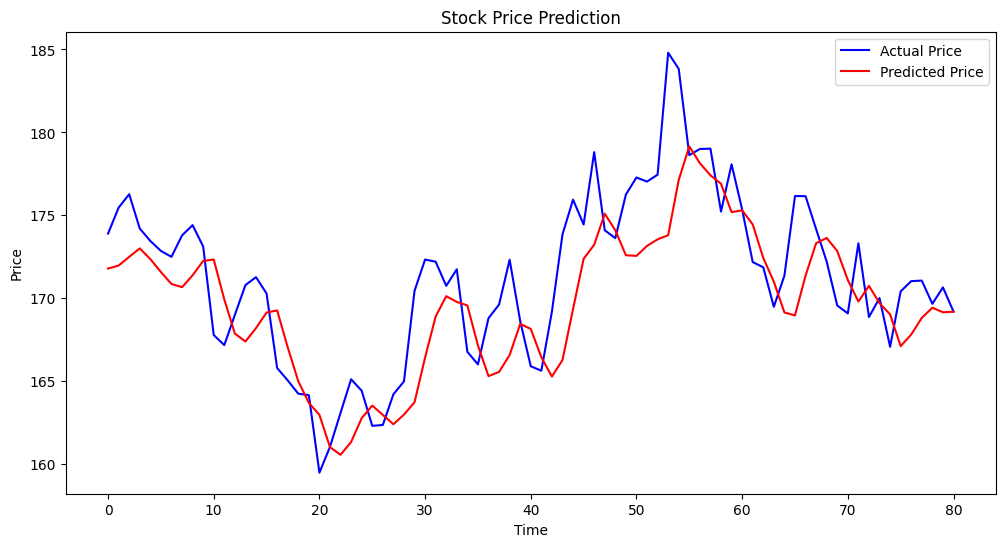

In [101]:
plt.figure(figsize=(12, 6))
plt.plot(actual_price, label='Actual Price', color='blue')
plt.plot(predicted_price, label='Predicted Price', color='red')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()